# Automatic Cointegrated Pair Selection

This notebook automatically finds cointegrated stock pairs from the NIFTY 50 universe.

Steps performed:
1. Load cleaned price dataset
2. Perform pairwise cointegration tests
3. Identify statistically significant pairs
4. Rank pairs based on p-values
5. Save top pairs for further trading analysis


## Import Required Libraries


In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import coint

## Load Processed Price Data


In [2]:
# Load cleaned NIFTY 50 price dataset
close_prices = pd.read_csv(
    "../data/processed/nifty50_close_prices.csv",
    index_col="Date",
    parse_dates=True
)

close_prices.head()

,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJFINANCE.NS,BAJAJFINSV.NS,BEL.NS,BAJAJHLDNG.NS,...,SBIN.NS,SUNPHARMA.NS,TCS.NS,TATACONSUM.NS,TATASTEEL.NS,TECHM.NS,TITAN.NS,ULTRACEMCO.NS,UPL.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2017-11-17,84.019249,382.822540,1028.840210,1098.098999,539.474731,2572.177246,174.075928,511.221161,50.817471,2520.500000,...,311.416840,478.927338,1109.047119,243.298660,53.673950,366.711548,764.456909,4117.043945,444.631989,101.002823
2017-11-20,86.058052,380.578796,1033.473267,1093.458374,542.209961,2600.370361,175.819260,515.586121,51.116055,2526.324463,...,307.264618,478.973694,1107.469971,257.340546,53.746670,360.846313,762.172058,4034.308105,447.517670,100.729050
2017-11-21,82.329216,382.679321,1080.484619,1087.786255,543.850952,2647.092041,176.257553,518.840088,50.461998,2540.907715,...,305.096222,498.330811,1094.975342,255.702332,54.450886,373.749908,792.797058,4017.037354,463.235107,100.609291
2017-11-22,84.663078,395.759888,1121.156372,1100.911499,537.584961,2657.479004,172.770859,515.865173,51.286686,2547.932861,...,309.386871,495.737488,1098.129517,256.544800,54.427929,365.235840,790.560913,4081.681885,458.691833,100.711952
2017-11-23,81.819511,388.694489,1111.451782,1087.130005,541.215393,2618.537842,171.767700,511.604767,53.206192,2573.276367,...,309.063934,504.536224,1098.375366,257.246887,54.554237,370.533508,783.512329,4038.022949,459.981140,100.455299


## Define Cointegration Detection Function


In [3]:
# Function to compute cointegration test for all stock pairs

def find_cointegrated_pairs(data):
    # numbers of assests
    n = data.shape[1]

    # matrices to store test results
    score_matrix = np.zeros((n, n))
    pvalue_matrix = np.ones((n, n))
    
    # list of tickers
    keys = data.columns
    pairs = []

    for i in range(n):
        for j in range(i+1, n):

            S1 = data[keys[i]]
            S2 = data[keys[j]]
            
            # perform Engle-Granger cointegration test
            score, pvalue, _ = coint(S1, S2)

            score_matrix[i, j] = score
            pvalue_matrix[i, j] = pvalue
            
            # store pairs with strong cointegration
            if pvalue < 0.01:
                pairs.append((keys[i], keys[j],pvalue))
    pairs=sorted(pairs,key=lambda x:x[2])  
    pairs=[(a, b) for a ,b, _ in pairs[:20]]          

    return score_matrix, pvalue_matrix, pairs

## Identify Cointegrated Pairs


In [4]:
scores, pvalues, pairs = find_cointegrated_pairs(close_prices)

print("Total cointegrated pairs found:", len(pairs))
pairs_df = pd.DataFrame(pairs, columns=["Stock1", "Stock2"])


pairs_df.head(20)
print("Top Cointegrated Pairs:")
print(pairs_df.head(10))

Total cointegrated pairs found: 20
Top Cointegrated Pairs:
          Stock1         Stock2
0    RELIANCE.NS  TATACONSUM.NS
1    HINDALCO.NS        SBIN.NS
2     HCLTECH.NS  ULTRACEMCO.NS
3  BAJAJ-AUTO.NS   POWERGRID.NS
4  APOLLOHOSP.NS  ULTRACEMCO.NS
5    AXISBANK.NS          LT.NS
6  ADANIPORTS.NS  ULTRACEMCO.NS
7       CIPLA.NS     HCLTECH.NS
8        NTPC.NS        ONGC.NS
9  BAJFINANCE.NS   KOTAKBANK.NS


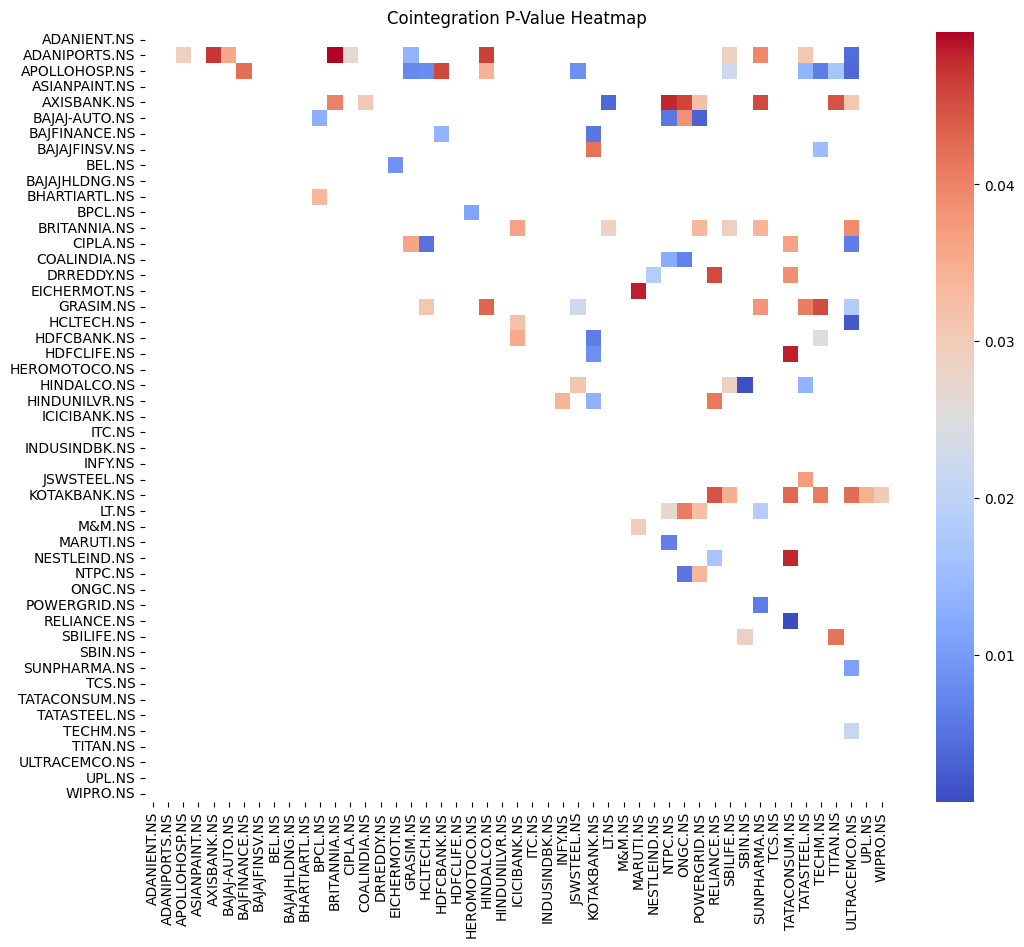

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

sns.heatmap(
    pvalues,
    xticklabels=close_prices.columns,
    yticklabels=close_prices.columns,
    cmap="coolwarm",
    mask=(pvalues >= 0.05)
)

plt.title("Cointegration P-Value Heatmap")

plt.savefig("../reports/cointegration_heatmap.png")

plt.show()

### Cointegration Results

The above output lists stock pairs whose price series show strong cointegration.

These pairs are potential candidates for statistical arbitrage strategies because their spreads tend to revert to a long-term equilibrium.


In [6]:
pairs_df = pd.DataFrame(pairs, columns=["Stock1","Stock2"])

pairs_df.to_csv("../data/processed/auto_cointegrated_pairs.csv", index=False)

print("Auto-selected cointegrated pairs saved successfully")


Auto-selected cointegrated pairs saved successfully


In [7]:
pvalue_df = pd.DataFrame(
    pvalues,
    index=close_prices.columns,
    columns=close_prices.columns
)

pvalue_df.to_csv("../data/processed/cointegration_pvalues.csv")

print("Cointegration p-value matrix saved")

Cointegration p-value matrix saved


### Output

The automatically selected cointegrated pairs are saved to:

data/processed/auto_cointegrated_pairs.csv

This dataset will be used in the next notebook to perform multi-pair portfolio backtesting.
